In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
path = "../reports/benchmark_results.json"

In [4]:
with open(path, "r") as f:
    benchmark_results = json.load(f)

benchmark_results_df = pd.DataFrame(benchmark_results)

In [5]:
benchmark_results_df

,index_type,params,recall_at_k,qps_mean,qps_median,qps_std,build_time_s,index_size_mb
0,IndexFlatIP,{},1.0000,23.493803,23.427547,0.105565,1.259552,2667.016644
1,IndexIVFFlat,"{'nlist': 100, 'nprobe': 1}",0.7914,475.246474,474.306044,17.088920,4.839345,2671.672992
2,IndexIVFFlat,"{'nlist': 100, 'nprobe': 5}",0.9733,88.094081,88.419608,0.586674,4.572629,2671.672992
3,IndexIVFFlat,"{'nlist': 100, 'nprobe': 10}",0.9906,45.421336,45.087635,0.543286,4.506845,2671.672992
4,IndexIVFFlat,"{'nlist': 100, 'nprobe': 20}",0.9954,23.523810,23.375943,0.312926,4.656017,2671.672992
5,IndexIVFFlat,"{'nlist': 100, 'nprobe': 50}",0.9960,10.676155,10.629624,0.111154,4.709908,2671.672992
6,IndexHNSWFlat,"{'M': 32, 'efConstruction': 200, 'efSearch': 16}",0.9279,6571.887926,5097.790510,2101.734811,366.017620,2808.766050
7,IndexHNSWFlat,"{'M': 32, 'efConstruction': 200, 'efSearch': 32}",0.9480,3337.522180,3333.339161,26.881907,364.335381,2808.766050
8,IndexHNSWFlat,"{'M': 32, 'efConstruction': 200, 'efSearch': 64}",0.9564,1677.192001,1675.017452,8.375691,372.353432,2808.766050
9,IndexHNSWFlat,"{'M': 32, 'efConstruction': 200, 'efSearch': 128}",0.9655,1073.749444,1106.238400,52.899460,372.270919,2808.766050


In [6]:
index_types = {
    index_name: group_df
    for index_name, group_df in benchmark_results_df.groupby("index_type")
}

flatIp_df = index_types["IndexFlatIP"]
ivf_df = index_types["IndexIVFFlat"]
hnsw_df = index_types["IndexHNSWFlat"]

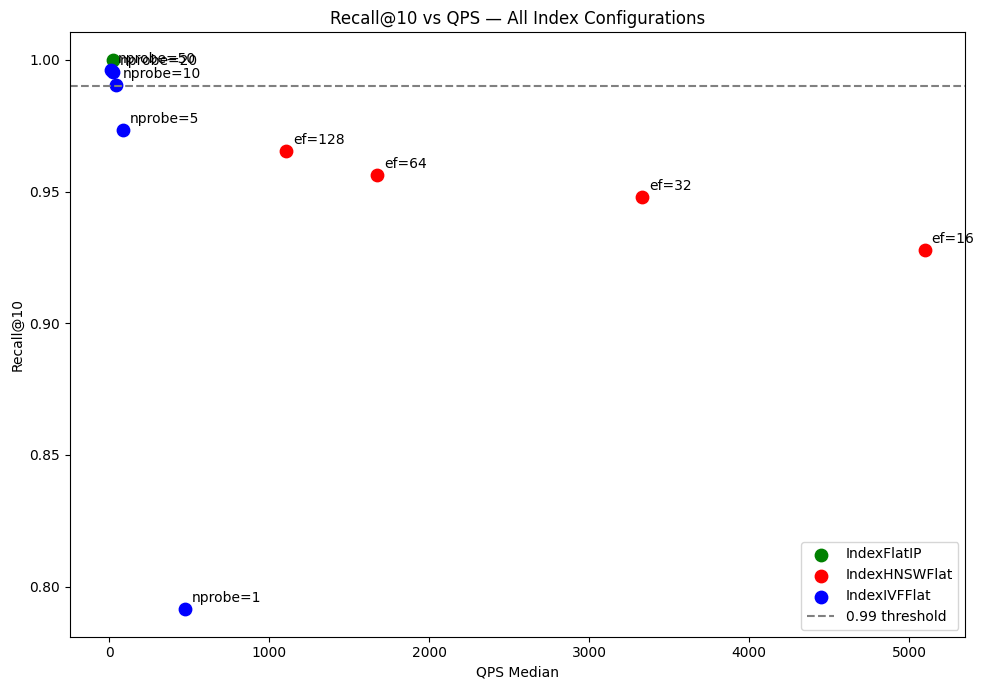

In [7]:
# Plot 1 Recall@10 vs QPS scatter

fig, ax = plt.subplots(figsize=(10, 7))

colors = {"IndexFlatIP": "green", "IndexIVFFlat": "blue", "IndexHNSWFlat": "red"}

for index_type, group in benchmark_results_df.groupby("index_type"):
    ax.scatter(group["qps_median"], group["recall_at_k"], 
               label=index_type, color=colors[index_type], s=80)

# Annotations
for _, row in ivf_df.iterrows():
    ax.annotate(f"nprobe={row['params']['nprobe']}", 
                (row["qps_median"], row["recall_at_k"]), textcoords="offset points", xytext=(5, 5))

for _, row in hnsw_df.iterrows():
    ax.annotate(f"ef={row['params']['efSearch']}", 
                (row["qps_median"], row["recall_at_k"]), textcoords="offset points", xytext=(5, 5))

ax.axhline(y=0.99, color="gray", linestyle="--", label="0.99 threshold")
ax.set_xlabel("QPS Median")
ax.set_ylabel("Recall@10")
ax.set_title("Recall@10 vs QPS — All Index Configurations")
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
ivf_df

,index_type,params,recall_at_k,qps_mean,qps_median,qps_std,build_time_s,index_size_mb
1,IndexIVFFlat,"{'nlist': 100, 'nprobe': 1}",0.7914,475.246474,474.306044,17.088920,4.839345,2671.672992
2,IndexIVFFlat,"{'nlist': 100, 'nprobe': 5}",0.9733,88.094081,88.419608,0.586674,4.572629,2671.672992
3,IndexIVFFlat,"{'nlist': 100, 'nprobe': 10}",0.9906,45.421336,45.087635,0.543286,4.506845,2671.672992
4,IndexIVFFlat,"{'nlist': 100, 'nprobe': 20}",0.9954,23.523810,23.375943,0.312926,4.656017,2671.672992
5,IndexIVFFlat,"{'nlist': 100, 'nprobe': 50}",0.9960,10.676155,10.629624,0.111154,4.709908,2671.672992


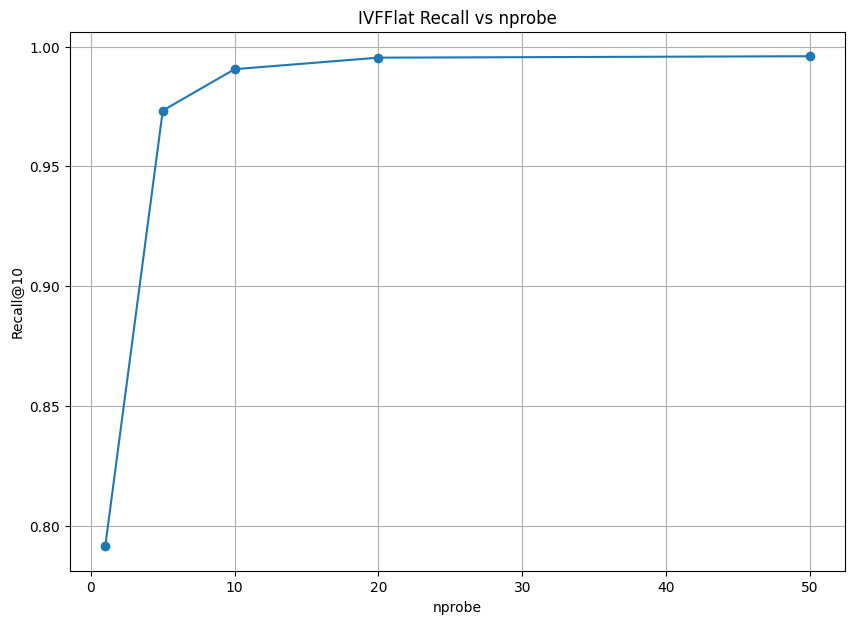

In [14]:
fig = plt.figure(figsize=(10, 7))
plt.plot(
    ivf_df["params"].apply(lambda x: x["nprobe"]),
    ivf_df["recall_at_k"],
    marker="o"
)
plt.xlabel("nprobe")
plt.ylabel("Recall@10")
plt.title("IVFFlat Recall vs nprobe")
plt.grid(True)
plt.show()